# A subspace normal operator

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrtoeplitz/blob/main/examples/subspace.ipynb)

`subspace_kernel`: the Gram of a fingerprinting acquisition — 500 frames, one
spoke each, a real dictionary basis — in fifteen transforms rather than five
hundred, checked against the definition.

In [1]:
try:
    import mrtoeplitz  # noqa: F401
except ImportError:
    %pip install -q "mrtoeplitz[nufft]" matplotlib finufft

In [2]:
from pathlib import Path
from time import perf_counter
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import torch

import mrtoeplitz as mt


def phantom(n=128):
    """A Shepp-Logan phantom on an n x n grid."""
    y, x = np.mgrid[-1 : 1 : n * 1j, -1 : 1 : n * 1j]
    ellipses = [
        # value, centre x, centre y, semi-axis a, semi-axis b, degrees
        (1.0, 0.0, 0.0, 0.69, 0.92, 0),
        (-0.8, 0.0, -0.0184, 0.6624, 0.874, 0),
        (-0.2, 0.22, 0.0, 0.11, 0.31, -18),
        (-0.2, -0.22, 0.0, 0.16, 0.41, 18),
        (0.1, 0.0, 0.35, 0.21, 0.25, 0),
        (0.1, 0.0, 0.1, 0.046, 0.046, 0),
        (0.1, 0.0, -0.1, 0.046, 0.046, 0),
        (0.1, -0.08, -0.605, 0.046, 0.023, 0),
        (0.1, 0.0, -0.606, 0.023, 0.023, 0),
        (0.1, 0.06, -0.605, 0.023, 0.046, 0),
    ]
    image = np.zeros((n, n))
    for value, cx, cy, a, b, degrees in ellipses:
        angle = np.deg2rad(degrees)
        xr = (x - cx) * np.cos(angle) + (y - cy) * np.sin(angle)
        yr = -(x - cx) * np.sin(angle) + (y - cy) * np.cos(angle)
        image[(xr / a) ** 2 + (yr / b) ** 2 <= 1.0] += value
    return image


# The temporal basis of a real fingerprinting scan: the leading components of
# the Deli-CS dictionary (Iyer, Schauman, Sandino et al., BSD), 500 frames.
local = Path("mrf_basis.npz")
if not local.exists():
    urlretrieve(
        "https://raw.githubusercontent.com/FiRMLAB-Pisa/mrtoeplitz/main/"
        "examples/mrf_basis.npz",
        local,
    )
loaded = np.load(local)
full_basis, signals = loaded["basis"], loaded["signals"]
tissue_signals = loaded["tissue_signals"]
tissue_names = list(loaded["tissue_names"])
n_frames = full_basis.shape[0]
print(f"basis {full_basis.shape} (frames, rank), {signals.shape[0]} dictionary signals")
print("tissues: " + ", ".join(
    f"{name} (T1 {t1} ms, T2 {t2} ms)"
    for name, t1, t2 in zip(tissue_names, loaded["tissue_t1"], loaded["tissue_t2"])
))

basis (500, 8) (frames, rank), 120 dictionary signals
tissues: white matter (T1 820 ms, T2 80 ms), grey matter (T1 1320 ms, T2 110 ms), CSF (T1 4000 ms, T2 500 ms), fat (T1 360 ms, T2 130 ms)


## What the subspace is for

A fingerprinting scan acquires hundreds of frames, each so undersampled that
it carries almost no image on its own. What makes it solvable is that the
frames are not independent: every voxel's signal over time is one of a
dictionary of trajectories through the Bloch equations, and that dictionary is
nearly low rank.

The basis below is the real one — the leading components of the Deli-CS
dictionary — so the rank is chosen by measurement rather than by taste.

In [3]:
# How many components the signals actually need.
residuals = []
for r in range(1, full_basis.shape[1] + 1):
    b = full_basis[:, :r]
    residuals.append(
        float(np.linalg.norm(signals - (signals @ b.conj()) @ b.T)
              / np.linalg.norm(signals))
    )
for r, value in enumerate(residuals, start=1):
    print(f"  rank {r}: {value:.3f} of the signal left unexplained")

rank = 5
basis = full_basis[:, :rank]          # (frames, rank) -- either orientation works
print(f"\nkeeping rank {rank}")

  rank 1: 0.477 of the signal left unexplained
  rank 2: 0.376 of the signal left unexplained
  rank 3: 0.126 of the signal left unexplained
  rank 4: 0.075 of the signal left unexplained
  rank 5: 0.051 of the signal left unexplained
  rank 6: 0.045 of the signal left unexplained
  rank 7: 0.037 of the signal left unexplained
  rank 8: 0.036 of the signal left unexplained

keeping rank 5


In [4]:
n = 128
# Fingerprinting samples one shot per frame and lets the frames, not the
# shots, fill k-space: every frame on its own is hopelessly undersampled,
# which is the reason a subspace is imposed at all.
n_samples = 256
golden = np.pi * (np.arange(n_frames) * (np.sqrt(5) - 1) / 2 % 1.0)
radius = np.linspace(-0.5, 0.5, n_samples, endpoint=False)
trajectory = np.stack(
    [
        np.stack([np.cos(a) * radius, np.sin(a) * radius], axis=-1)[None]
        for a in golden
    ]
).astype(np.float32)
density = np.linalg.norm(trajectory, axis=-1).astype(np.float32)
print(f"trajectory {trajectory.shape} (frames, shots, points, axes)")
print(f"one spoke per frame for a {n}x{n} image: "
      f"{100 * n_samples / (np.pi / 2 * n * n):.1f}% of Nyquist, per frame")

trajectory (500, 1, 256, 2) (frames, shots, points, axes)
one spoke per frame for a 128x128 image: 1.0% of Nyquist, per frame


## One transform per basis pair

A subspace normal is not one normal per frame. Expanding the definition, the
frames collapse into `rank (rank + 1) / 2` gridding transforms — one per pair
of basis vectors, over every frame's samples at once. At rank 5 that is
fifteen transforms for five hundred frames, and it does not grow with the
scan.

`trajectory` is `(shots, points, axes)` when every frame shares one and
`(frames, shots, points, axes)` when they differ. `basis` may be
`(frames, rank)` or `(rank, frames)`: which one it is is read off the data.

In [5]:
start = perf_counter()
kernel = mt.subspace_kernel(trajectory, basis, (n, n), density=density)
elapsed = perf_counter() - start

pairs = rank * (rank + 1) // 2
print(kernel)
print(f"built in {elapsed:.2f} s from {pairs} gridding transforms, not {n_frames}:")
print("one per basis pair, over every frame's samples at once.")
print(f"stored {kernel.storage_nbytes / 2**20:.2f} MiB of a dense "
      f"{kernel.dense_nbytes / 2**20:.2f} MiB ({kernel.compression_ratio:.2f}x)")

PolyphaseToeplitzKernel(rank=5, image_shape=(128, 128), components=4, compression=3.83x)
built in 0.24 s from 15 gridding transforms, not 500:
one per basis pair, over every frame's samples at once.
stored 6.53 MiB of a dense 25.00 MiB (3.83x)


## Coefficients, and why they do not look alike

Every tissue has its own signal evolution, so every tissue projects onto the
basis differently. The components that come out are not one image scaled: they
carry different contrast, which is what makes the subspace a compression of
the scan rather than of the image.

## Is it the subspace Gram?

The reference is the definition, run the slow way: expand the coefficients
into each of the five hundred frames, grid that frame with raw FINUFFT, weight
it, project back onto the basis.

In [6]:
import finufft


def exact_subspace_gram(coefficients):
    """The definition: expand to every frame, grid it, project back.

    Five hundred frames, one at a time, with nothing from the package in it.
    """
    out = np.zeros_like(coefficients)
    forward = finufft.Plan(2, (n, n), isign=-1, eps=1e-9, dtype="complex128")
    adjoint = finufft.Plan(1, (n, n), isign=+1, eps=1e-9, dtype="complex128")
    for frame in range(n_frames):
        points = np.ascontiguousarray(
            trajectory[frame].reshape(-1, 2).astype(np.float64) * 2 * np.pi
        )
        columns = [np.ascontiguousarray(points[:, axis]) for axis in range(2)]
        forward.setpts(*columns)
        adjoint.setpts(*columns)
        expanded = sum(basis[frame, i] * coefficients[i] for i in range(rank))
        measured = forward.execute(expanded.astype(np.complex128))
        measured = measured * density[frame].reshape(-1).astype(np.float64)
        back = adjoint.execute(measured) / (2 * n) ** 2
        for j in range(rank):
            out[j] += np.conj(basis[frame, j]) * back
    return out


# Coefficient maps of an object made of tissues, not one image scaled five
# ways: each tissue's signal evolution projects differently onto the basis, so
# the components carry genuinely different contrast. Scaling one image would
# give five copies of it and prove nothing.
labels = phantom(n)
y, x = np.mgrid[-1 : 1 : n * 1j, -1 : 1 : n * 1j]
head = ((x / 0.69) ** 2 + (y / 0.92) ** 2) <= 1.0
compartments = {
    "fat": labels > 0.6,                                   # the skull
    "grey matter": (labels > 0.25) & (labels <= 0.6),      # the small structures
    "white matter": (labels > 0.15) & (labels <= 0.25),    # the bulk
    "CSF": head & (labels <= 0.05),                        # the ventricles
}
for name, mask in compartments.items():
    print(f"  {name:>13}: {100 * mask.mean():5.1f}% of the frame")
coefficients = np.zeros((rank, n, n), dtype=np.complex64)
for name, mask in compartments.items():
    signal = tissue_signals[tissue_names.index(name)]
    weights = signal @ basis.conj()          # (rank,) for this tissue
    coefficients[:, mask] = weights[:, None]

print("coefficient of each tissue on each component (magnitude):")
print(f"{'':>14}" + "".join(f"{'c' + str(k):>9}" for k in range(rank)))
for name in ("white matter", "grey matter", "CSF"):
    weights = tissue_signals[tissue_names.index(name)] @ basis.conj()
    print(f"{name:>14}" + "".join(f"{abs(v):9.3f}" for v in weights))

start = perf_counter()
truth = exact_subspace_gram(coefficients)
definition = perf_counter() - start
start = perf_counter()
fast = kernel(torch.as_tensor(coefficients)[None])[0].numpy()
applied = perf_counter() - start

error = np.linalg.norm(fast - truth) / np.linalg.norm(truth)
print(f"relative error against the definition: {error:.2e}")
print(f"the definition took {definition:.2f} s, the kernel {1e3 * applied:.0f} ms "
      f"({definition / applied:.0f}x)")

            fat:   4.3% of the frame
    grey matter:   4.4% of the frame
   white matter:  32.7% of the frame
            CSF:   7.6% of the frame
coefficient of each tissue on each component (magnitude):
                     c0       c1       c2       c3       c4
  white matter    0.930    0.300    0.207    0.031    0.010
   grey matter    0.964    0.251    0.045    0.075    0.014
           CSF    0.528    0.183    0.798    0.194    0.075


relative error against the definition: 5.59e-04
the definition took 8.93 s, the kernel 16 ms (569x)


The residual is support compression, not the subspace: the transfer is kept
only where the trajectory reached, and the decimal digits that costs are the
currency the package spends to buy memory. `toeplitz_options(compress=False)`
buys them back at the cost of the whole doubled grid.

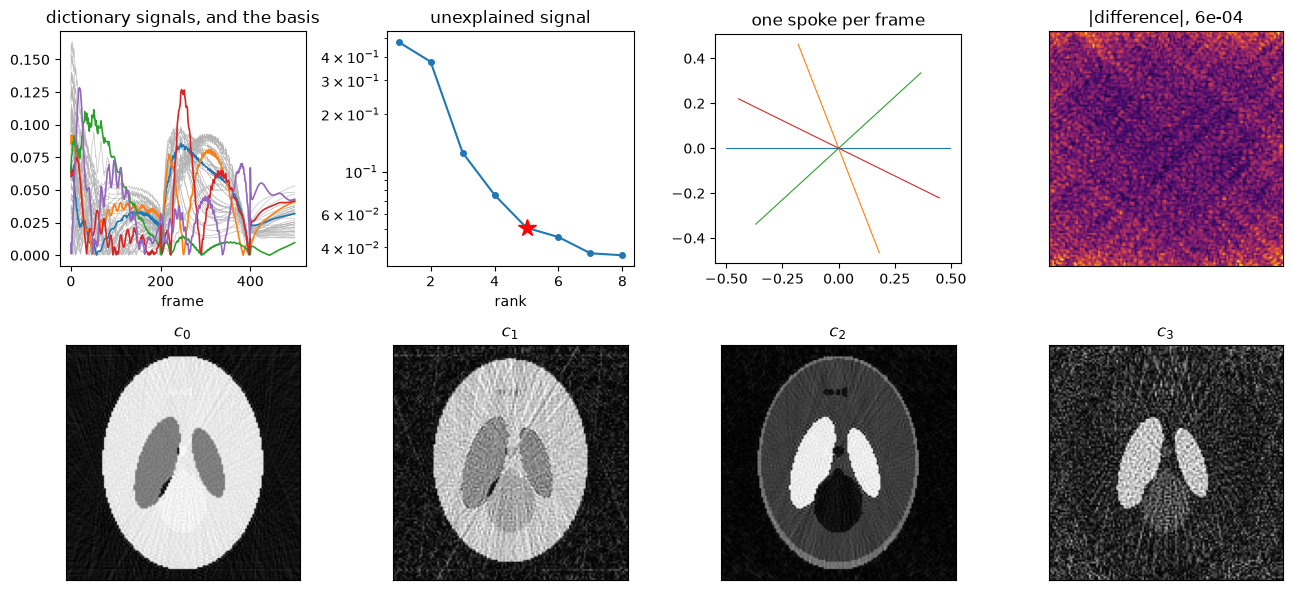

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
axes[0, 0].plot(np.abs(signals[:40].T), linewidth=0.4, color="0.7")
axes[0, 0].plot(np.abs(full_basis[:, :rank]), linewidth=1.2)
axes[0, 0].set_title("dictionary signals, and the basis")
axes[0, 0].set_xlabel("frame")

axes[0, 1].semilogy(range(1, len(residuals) + 1), residuals, "o-", markersize=4)
axes[0, 1].plot(rank, residuals[rank - 1], "r*", markersize=13)
axes[0, 1].set_title("unexplained signal")
axes[0, 1].set_xlabel("rank")

axes[0, 2].plot(
    trajectory[0, 0, :, 0], trajectory[0, 0, :, 1], linewidth=0.8, label="frame 0"
)
for frame in (1, 2, 3):
    axes[0, 2].plot(
        trajectory[frame, 0, :, 0], trajectory[frame, 0, :, 1], linewidth=0.8
    )
axes[0, 2].set_title("one spoke per frame")
axes[0, 2].set_aspect("equal")

axes[0, 3].imshow(np.abs(fast - truth).sum(0) / np.abs(truth).max(), cmap="inferno")
axes[0, 3].set_title(f"|difference|, {error:.0e}")
axes[0, 3].set_xticks([])
axes[0, 3].set_yticks([])

for component in range(4):
    panel = np.abs(fast[component])
    axes[1, component].imshow(panel, cmap="gray", vmax=np.percentile(panel, 99.5))
    axes[1, component].set_title(f"$c_{component}$")
    axes[1, component].set_xticks([])
    axes[1, component].set_yticks([])
fig.tight_layout()

In [8]:
# Written only when the notebook runs inside a clone, and it is what the
# README shows -- so the figure in the README is always this cell's output.
figures = Path("figures")
if figures.is_dir():
    fig.savefig(figures / "subspace.png", dpi=110, bbox_inches="tight")

## Frames that share a trajectory

Grouping happens before any gridding, so the build follows the number of
*distinct* trajectories rather than the number of frames — which is the
difference between a golden-angle scan and one that cycles a fixed set of
rotations.

In [9]:
# A scan whose frames cycle through a handful of rotations is a different
# problem: frames are grouped by trajectory before any gridding, so a repeated
# rotation is gridded once however many frames use it.
def time_build(traj, dens):
    start = perf_counter()
    mt.subspace_kernel(traj, basis, (n, n), density=dens)
    return perf_counter() - start


cycled = np.stack([trajectory[index % 8] for index in range(n_frames)])
cycled_density = np.linalg.norm(cycled, axis=-1).astype(np.float32)
distinct = time_build(trajectory, density)
repeated = time_build(cycled, cycled_density)
print(f"{n_frames} distinct trajectories: {distinct:5.2f} s")
print(f"{n_frames} frames over 8 of them: {repeated:5.2f} s  "
      f"({distinct / repeated:.1f}x)")

500 distinct trajectories:  0.24 s
500 frames over 8 of them:  0.15 s  (1.6x)
